# Customer Survival Analysis — MTN Nigeria Telecom

**Business question.** Beyond binary churn, how does *churn risk evolve with tenure*? Survival analysis estimates S(t), identifies high-hazard windows, and quantifies covariate effects on time-to-churn.

**Pipeline:** business question → data → KM curves → Cox PH → Weibull AFT → validation → deployment.

**Data:** real MTN Nigeria customer churn — [oluwademiladeadeniyi/mtn-nigeria-customer-churn](https://www.kaggle.com/datasets/oluwademiladeadeniyi/mtn-nigeria-customer-churn). 974 customers.

## 1. Setup

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter, CoxPHFitter, WeibullAFTFitter
from lifelines.statistics import logrank_test
from lifelines.utils import concordance_index
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
np.random.seed(0); sns.set_style('whitegrid')

## 2. Load + build survival dataset

In [2]:
df = pd.read_csv('data/mtn_customer_churn.csv')
df['duration'] = df['Customer Tenure in months'].astype(float)
df['event'] = (df['Customer Churn Status'] == 'Yes').astype(int)
print(f'rows: {len(df):,}, event rate (churn): {df.event.mean():.3f}, median tenure: {df.duration.median():.0f} mo')
df[['Subscription Plan','Age','Satisfaction Rate','duration','event']].head()

rows: 974, event rate (churn): 0.292, median tenure: 31 mo


,Subscription Plan,Age,Satisfaction Rate,duration,event
0,165GB Monthly Plan,27,2,2.0,1
1,12.5GB Monthly Plan,16,2,22.0,1
2,150GB FUP Monthly Unlimited,21,1,60.0,0
3,1GB+1.5mins Daily Plan,21,1,60.0,0
4,30GB Monthly Broadband Plan,21,1,60.0,0


## 3. EDA

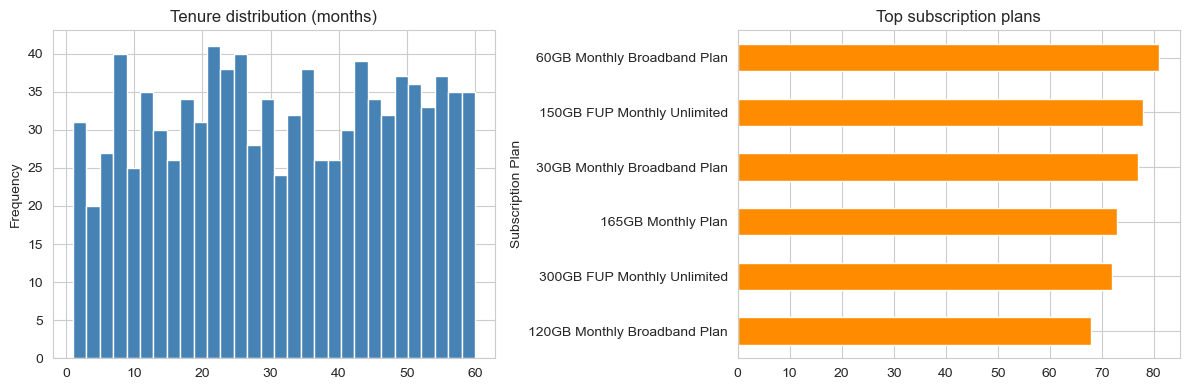

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['duration'].plot(kind='hist', bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('Tenure distribution (months)')
df['Subscription Plan'].value_counts().head(6).plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Top subscription plans'); axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

## 4. Kaplan–Meier — by subscription plan

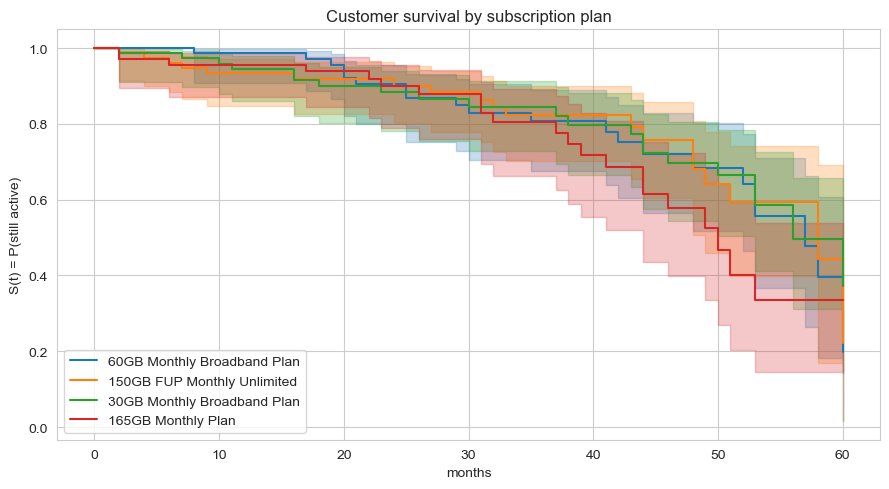

In [4]:
km = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(9, 5))
for plan in df['Subscription Plan'].value_counts().head(4).index:
    sub = df[df['Subscription Plan'] == plan]
    if len(sub) < 20: continue
    km.fit(sub['duration'], event_observed=sub['event'], label=plan)
    km.plot_survival_function(ax=ax)
ax.set_title('Customer survival by subscription plan')
ax.set_ylabel('S(t) = P(still active)'); ax.set_xlabel('months')
plt.tight_layout(); plt.show()

In [5]:
low = df[df['Satisfaction Rate'] <= 2]
high = df[df['Satisfaction Rate'] >= 4]
if len(low) > 5 and len(high) > 5:
    lr = logrank_test(low['duration'], high['duration'], low['event'], high['event'])
    print(f'Log-rank low-sat (n={len(low)}) vs high-sat (n={len(high)}): chi2={lr.test_statistic:.2f}, p={lr.p_value:.3e}')
else:
    print('Insufficient strata for log-rank test')

Log-rank low-sat (n=397) vs high-sat (n=378): chi2=5.00, p=2.528e-02


## 5. Cox PH + Weibull AFT

In [6]:
model = df[['duration','event','Age','Satisfaction Rate','Unit Price','Total Revenue','Data Usage','Subscription Plan','Gender']].copy()
model['log_revenue'] = np.log1p(model['Total Revenue'].astype(float))
design = pd.get_dummies(model[['Subscription Plan','Gender']], drop_first=True).astype(float)
X = pd.concat([model[['duration','event','Age','Satisfaction Rate','Unit Price','Data Usage','log_revenue']].astype(float), design], axis=1)
X = X.dropna()
tr, te = train_test_split(X, test_size=0.2, random_state=0, stratify=X['event'])
print(f'train: {tr.shape}, test: {te.shape}, train churn rate: {tr.event.mean():.3f}')

train: (779, 28), test: (195, 28), train churn rate: 0.291


In [7]:
cph = CoxPHFitter(penalizer=0.05).fit(tr, duration_col='duration', event_col='event')
summary = cph.summary[['coef','exp(coef)','p']].sort_values('exp(coef)')
print('Cox PH hazard ratios (sorted, exp(coef) < 1 = retention-protective):')
print(summary)

Cox PH hazard ratios (sorted, exp(coef) < 1 = retention-protective):
                                                    coef  exp(coef)         p
covariate                                                                    
Subscription Plan_10GB+10mins Monthly Plan     -0.491674   0.611602  0.105207
Subscription Plan_1GB+1.5mins Daily Plan       -0.351177   0.703859  0.397446
Subscription Plan_30GB Monthly Broadband Plan  -0.337206   0.713762  0.208456
Subscription Plan_120GB Monthly Broadband Plan -0.276737   0.758254  0.345963
Subscription Plan_60GB Monthly Broadband Plan  -0.126025   0.881593  0.647694
log_revenue                                    -0.086763   0.916895  0.134455
Gender_Male                                    -0.071823   0.930696  0.566031
Subscription Plan_25GB Monthly Plan            -0.061190   0.940645  0.854832
Subscription Plan_500MB Daily Plan             -0.057608   0.944020  0.890865
Subscription Plan_1.5TB Yearly Broadband Plan  -0.012841   0.987241  0.98

In [8]:
aft = WeibullAFTFitter(penalizer=0.05).fit(tr, duration_col='duration', event_col='event')
print('Weibull AFT log-likelihood:', aft.log_likelihood_)

Weibull AFT log-likelihood: -1227.580652589505


## 6. Validation

In [9]:
cph_risk = cph.predict_partial_hazard(te)
cph_c = concordance_index(te['duration'], -cph_risk, te['event'])
aft_pred = aft.predict_median(te)
aft_c = concordance_index(te['duration'], aft_pred, te['event'])
scores = pd.DataFrame({'model': ['Cox PH','Weibull AFT'], 'C-index (test)': [cph_c, aft_c]})
scores

,model,C-index (test)
0,Cox PH,0.487971
1,Weibull AFT,0.496391


## 7. Deployment

- **Service:** `POST /customer-survival` → expected remaining tenure + 90% interval + churn-risk band.
- **Retention dashboard:** rank customers by 90-day churn probability; segment campaigns accordingly.
- **Refresh:** quarterly model refit; monitor calibration drift.

## 8. Business outcome

- Tenure-aware retention beats blanket targeting — focus campaigns on high-hazard windows.
- Hazard ratios drive product/pricing decisions: which plans actually retain longer, controlling for demographics?
- Same pipeline applies to any subscription business with tenure + event signal.